# Import Essential Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from sklearn.model_selection  import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import LabelEncoder,StandardScaler

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

# Load the Data

In [2]:
student_data = pd.read_csv("/home/talha/Projects/student-score-project/datasets/student_data.csv")

# Basic of data exploration

# Head of dataset
print('='*12,'Head of Dataset','='*12)
print(student_data.head())
# Tail of data set
print('='*12,'Tail of Dataset','='*12)
print(student_data.tail())
# Info of Dataset
print('='*12,'Info of Dataset','='*12)
print(student_data.info())
# Missing values
print('='*12,'Missing values in Dataset','='*12)
print(student_data.isnull().sum())

============ Head of Dataset ============
   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        no

       student_id  age  gender school_type parent_education  study_hours  \
24995       12047   17  female      public              phd          1.8   
24996        1102   16  female     private          diploma          2.7   
24997        4422   19   other     private    post graduate          1.0   
24998        7858   14    male     private          diploma          1.0   
24999       11621   18   other      public        no formal          0.7   

       attendance_percentage internet_access travel_time extra_activities  \
24995                   55.2             yes   15-30 min               no   
24996                   97.1             yes     <15 min               no   
24997                   63.0             yes     <15 min               no   
24998                   69.4             yes   15-30 min              yes   
24999                   60.3             yes   30-60 min               no   

      study_method  math_score  science_score  english_score  overall_score  \
2

# Exploratory Data Analysis (EDA)

Distribution of Final Grades

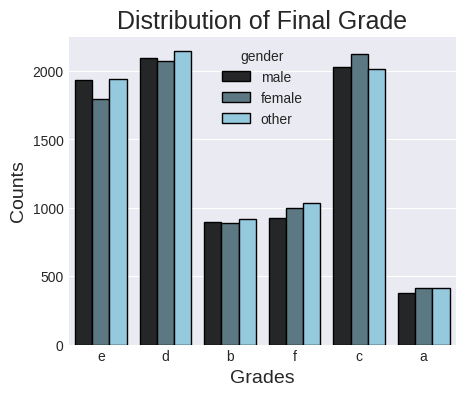

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
#  Distrubutive of final grade
plt.figure(figsize = (5,4))

sns.countplot(data= student_data,x= "final_grade", hue="gender", color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grade',fontsize=18)
plt.xlabel('Grades',fontsize=14)
plt.ylabel('Counts',fontsize=14)
# plt.xticks(rotation=1)
plt.show()



 Correlation Graph

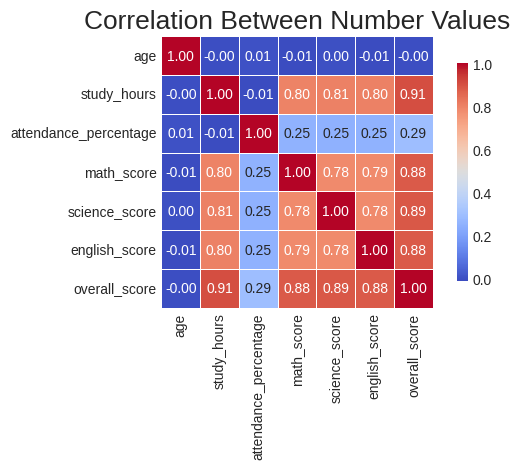

In [4]:
numerical_col = student_data.select_dtypes(exclude='object').drop('student_id',axis=1)
corr = numerical_col.corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidth=0.5,
            cbar_kws={'shrink':0.8})
plt.title('Correlation Between Number Values',fontsize=19 )
plt.tight_layout()
plt.show()

Subjects Wise Comparison of Scores

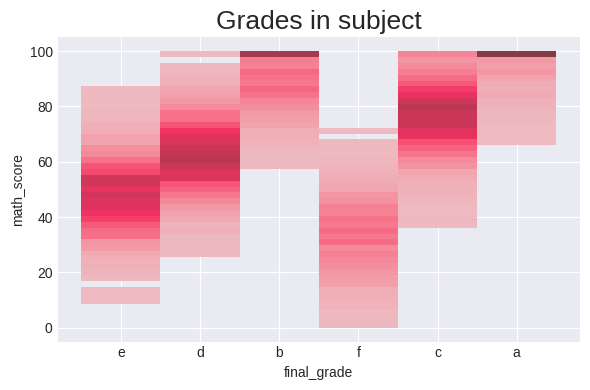

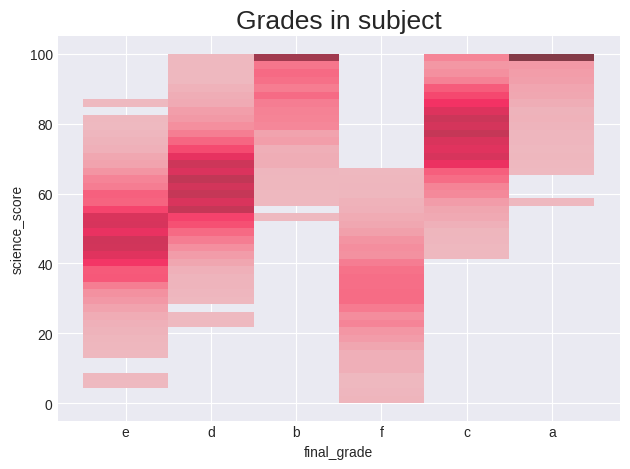

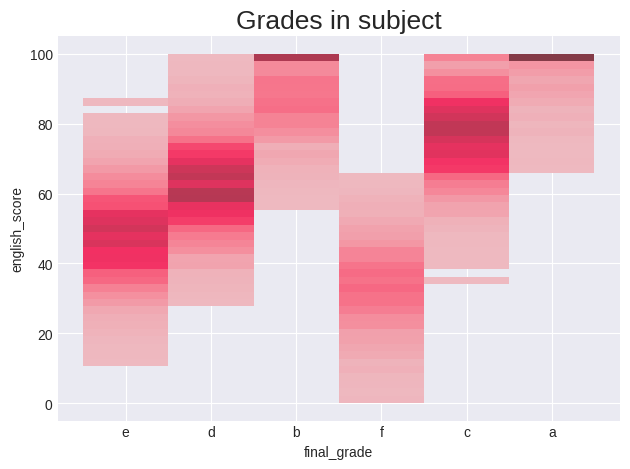

In [5]:
subject_col = ['math_score','science_score','english_score']

plt.figure(figsize=(6,4))

for i,subject in enumerate(subject_col):
   # plt.subplot(1,3,i+1)
    sns.histplot(data=student_data,x='final_grade',y=subject,linewidth=0.5)
    plt.title('Grades in subject',fontsize= 19)
    plt.tight_layout()
    plt.show()

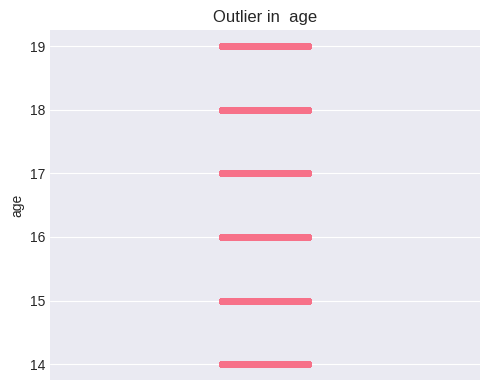

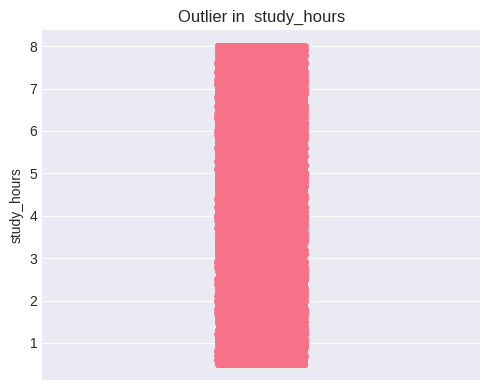

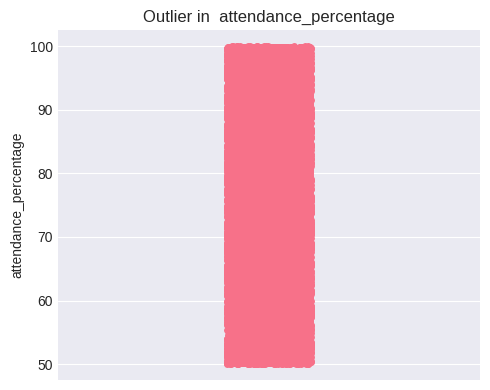

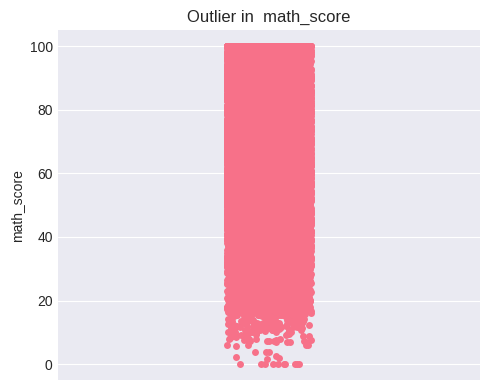

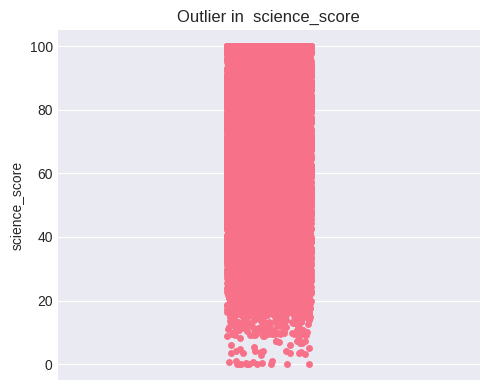

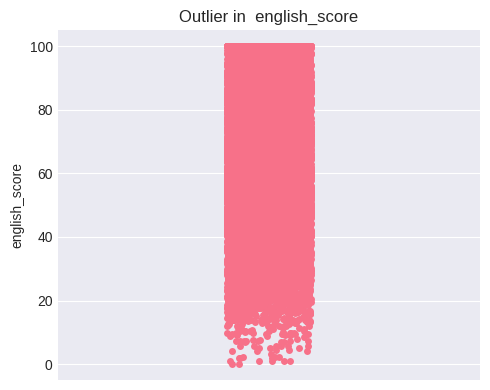

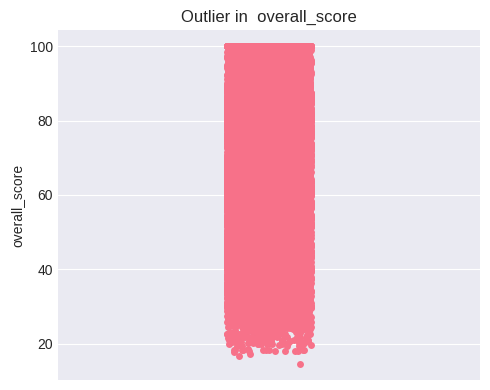

In [24]:
for i,subject in enumerate(numerical_col,1):
    plt.figure(figsize=(5,4))
    sns.stripplot(y=student_data[subject])
    plt.title(f'Outlier in  {subject}')
    plt.tight_layout()
    plt.show()

In [ ]:
categorical_data = student_data.data_types(include='object')
for i,categorical in enumerate(categorical_data,1):
    

In [7]:
student_data.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='object')